<a href="https://colab.research.google.com/github/rizanatlanta-dsproj/Spam-Email-Detection/blob/main/Spamdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Spam Detection Project
# Dataset Recommended by: Supervisor Sk Asrafuzzaman (Head lecturer, Ict)


Week 1: Research, Dataset Collection, Dataset Preprocessing

In [2]:
#Importing Libraries

In [3]:
!pip install xgboost dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 748.4 kB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay



In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore")


In [6]:
!pip install opendatasets

In [7]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rizanatlanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset


100%|██████████| 2.86M/2.86M [00:00<00:00, 711MB/s]

In [8]:
import pandas as pd
data = pd.read_csv('/content/spam-email-dataset/emails.csv')

In [9]:
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [10]:
data.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [11]:
print(data.shape)

(5728, 2)


In [12]:
data.drop_duplicates(inplace=True)
print(data.shape)

(5695, 2)


In [13]:
print(data.isnull().sum())

text    0
spam    0
dtype: int64


In [14]:
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [15]:
data['Category'] = data['spam'].replace([1, 0], ['Spam', 'Not Spam'])

In [16]:
data.head()

,text,spam,Category
0,Subject: naturally irresistible your corporate...,1,Spam
1,Subject: the stock trading gunslinger fanny i...,1,Spam
2,Subject: unbelievable new homes made easy im ...,1,Spam
3,Subject: 4 color printing special request add...,1,Spam
4,"Subject: do not have money , get software cds ...",1,Spam


In [17]:
data.tail()

,text,spam,Category
5723,Subject: re : research and development charges...,0,Not Spam
5724,"Subject: re : receipts from visit jim , than...",0,Not Spam
5725,Subject: re : enron case study update wow ! a...,0,Not Spam
5726,"Subject: re : interest david , please , call...",0,Not Spam
5727,Subject: news : aurora 5 . 2 update aurora ve...,0,Not Spam


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5695 entries, 0 to 5727
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      5695 non-null   object
 1   spam      5695 non-null   int64 
 2   Category  5695 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.0+ KB


<Axes: >

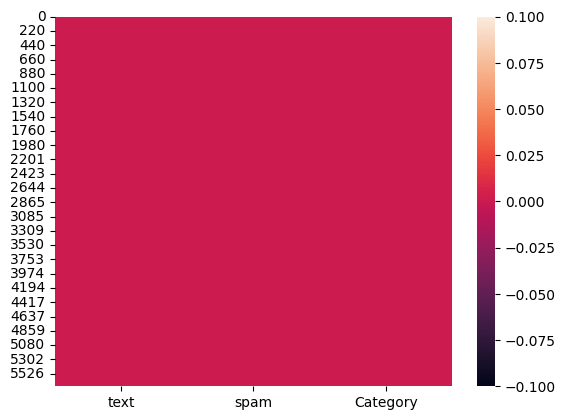

In [19]:
sns.heatmap(data.isnull())

In [20]:
data = data.iloc[:, 1:]

In [21]:
data

,spam,Category
0,1,Spam
1,1,Spam
2,1,Spam
3,1,Spam
4,1,Spam
...,...,...
5723,0,Not Spam
5724,0,Not Spam
5725,0,Not Spam
5726,0,Not Spam


In [22]:
data.nunique()

,0
spam,2
Category,2


<Axes: xlabel='Category', ylabel='count'>

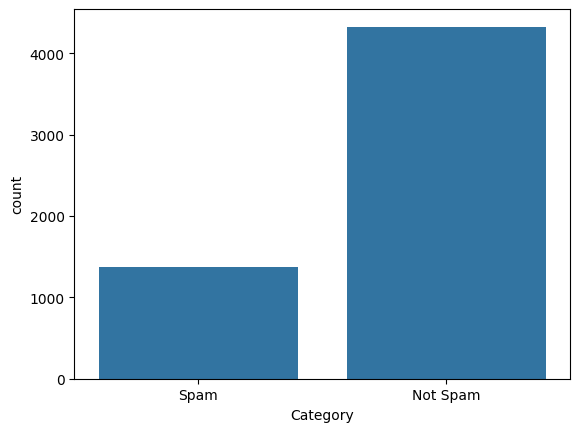

In [23]:
sns.countplot(x='Category', data=data)

In [24]:
x= data.iloc[:,:3000].values
x

array([[1, 'Spam'],
       [1, 'Spam'],
       [1, 'Spam'],
       ...,
       [0, 'Not Spam'],
       [0, 'Not Spam'],
       [0, 'Not Spam']], dtype=object)

In [25]:
y = data.iloc[:, -1].values
y

array(['Spam', 'Spam', 'Spam', ..., 'Not Spam', 'Not Spam', 'Not Spam'],
      dtype=object)

Train and Test Splitting the data

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

Performance Measurement and Showing Matrix

In [27]:
def perform(y_true, y_pred):
    print("Precision : ", precision_score(y_true, y_pred))
    print("Recall : ", recall_score(y_true, y_pred))
    print("Accuracy Score : ", accuracy_score(y_true, y_pred))
    print("F1 Score : ", f1_score(y_true, y_pred))
    print("\n", confusion_matrix(y_true, y_pred))
    print("")

    cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_true, y_pred), display_labels=['Spam', 'Not Spam'] )
    cm_display.plot()
    plt.show()


### Week 2: Model training

## Multinomial Naive Bayes

##comment by Asif Sir
# Re-load Original Data

### Subtask:
Load the `emails.csv` dataset again, ensuring that the original 'text' column is retained. This column is critical for actual spam detection.


**Reasoning by Asif Sir**:
The subtask requires loading the `emails.csv` dataset again, ensuring the 'text' column is retained, and storing it in a new DataFrame called `data_new`. The pandas library is already imported, so I will directly proceed with loading the CSV file.



In [28]:
data_new = pd.read_csv('/content/spam-email-dataset/emails.csv')
print("Original data loaded successfully into 'data_new' DataFrame.")
data_new.head()

Original data loaded successfully into 'data_new' DataFrame.


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [29]:
X = data_new['text']
y = data_new['spam']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: object

Target (y) head:
0    1
1    1
2    1
3    1
4    1
Name: spam, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4009,)
Shape of X_test: (1719,)
Shape of y_train: (4009,)
Shape of y_test: (1719,)


### Vectorize the Text Data using TF-IDF


Text data cannot be directly fed into machine learning models. It needs to be converted into numerical features. TF-IDF (Term Frequency-Inverse Document Frequency) is a statistical measure that evaluates how relevant a word is to a document in a collection of documents. This step will transform the `X_train` and `X_test` text data into numerical vectors, making it suitable for model training.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)


Shape of X_train_tfidf: (4009, 5000)
Shape of X_test_tfidf: (1719, 5000)


In [32]:
from sklearn.naive_bayes import MultinomialNB

model_mnb = MultinomialNB()
model_mnb.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [33]:
y_pred_mnb = model_mnb.predict(X_test_tfidf)
print("Predictions made on the test set.")

Predictions made on the test set.


Precision :  0.9855421686746988
Recall :  0.927437641723356
Accuracy Score :  0.9778941244909831
F1 Score :  0.955607476635514

 [[1272    6]
 [  32  409]]



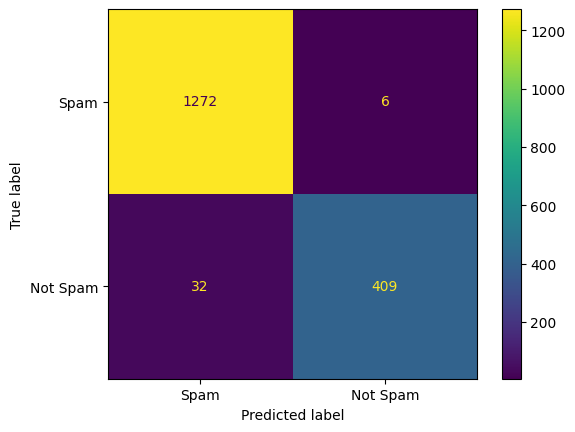

In [34]:
perform(y_test, y_pred_mnb)

## XGboost classifier

In [35]:
xgb_classifier = XGBClassifier()
xgb_classifier.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [36]:
y_pred_xgb = xgb_classifier.predict(X_test_tfidf)

Precision :  0.9615384615384616
Recall :  0.963718820861678
Accuracy Score :  0.9808027923211169
F1 Score :  0.9626274065685164

 [[1261   17]
 [  16  425]]



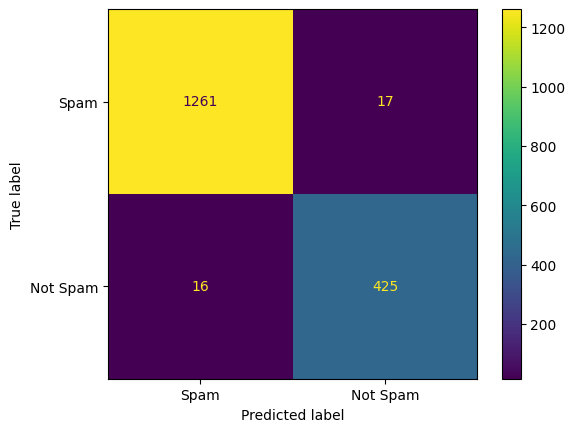

In [37]:
perform(y_test, y_pred_xgb)

## Decision Tree

In [38]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [39]:
y_pred_dt = model_dt.predict(X_test_tfidf)

Precision :  0.9435294117647058
Recall :  0.909297052154195
Accuracy Score :  0.9627690517742874
F1 Score :  0.9260969976905312

 [[1254   24]
 [  40  401]]



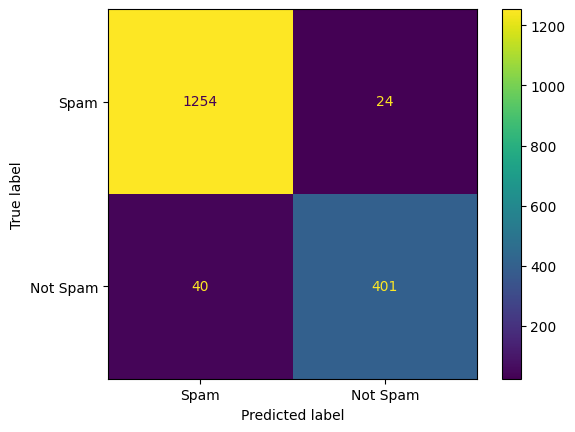

In [40]:
perform(y_test, y_pred_dt)

## Decision Tree Visualization using Scikit-learn

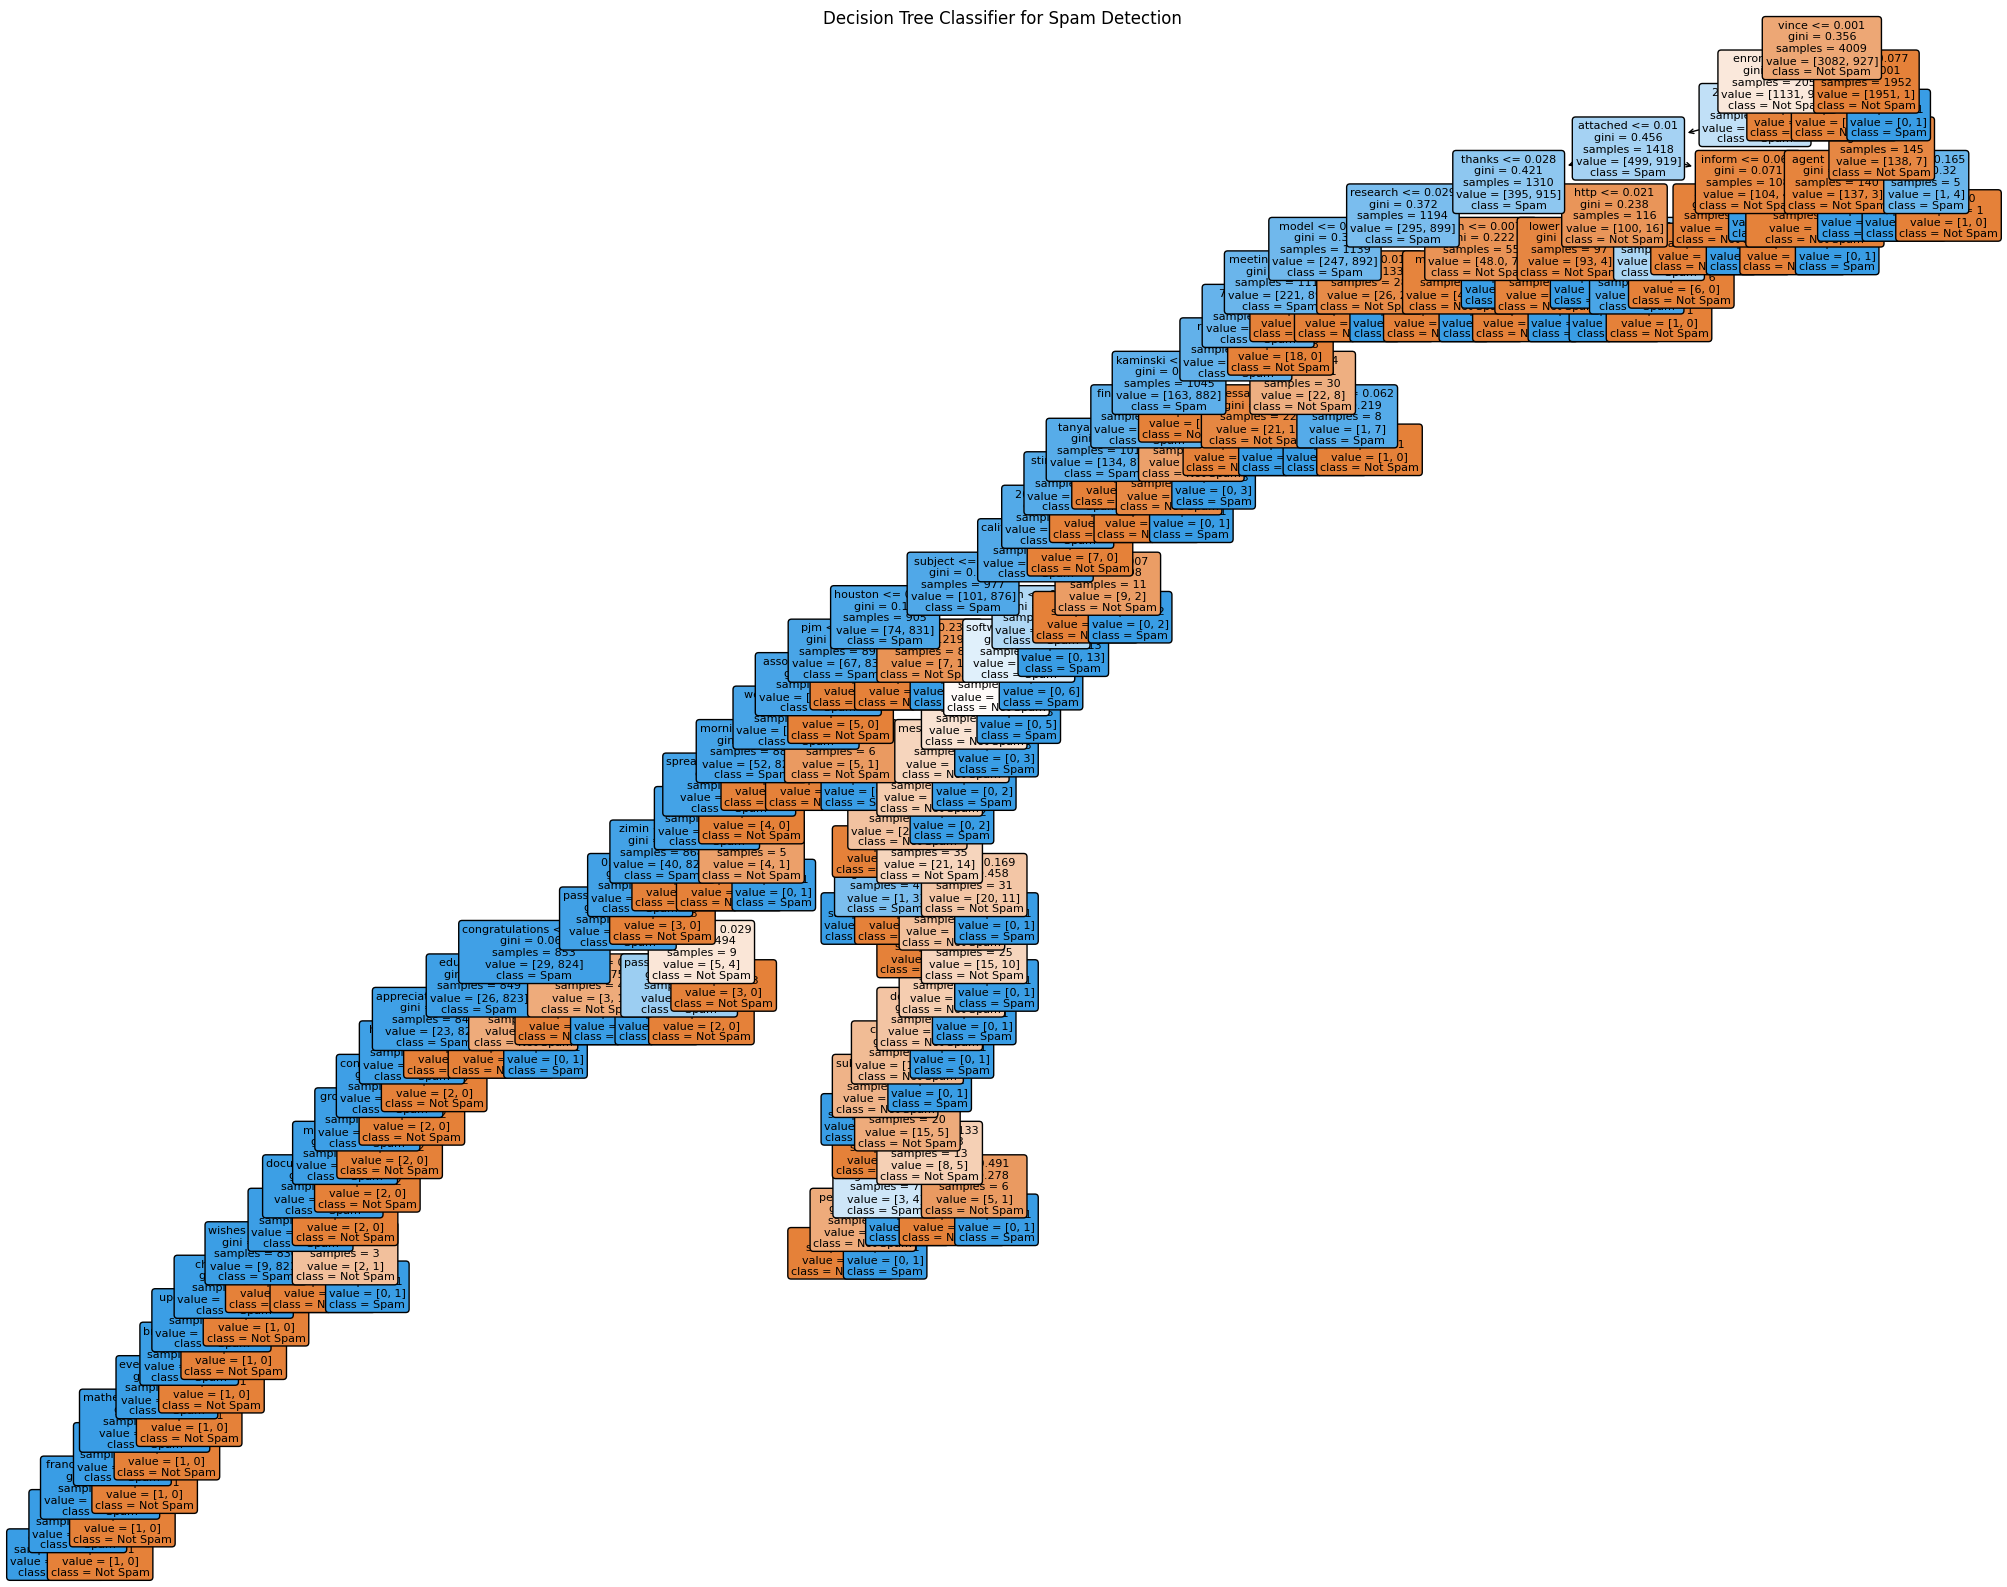

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Define feature_names from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Define class_names based on your target variable (0 for Not Spam, 1 for Spam)
class_names = ['Not Spam', 'Spam']

# Set a larger figure size for better readability
plt.figure(figsize=(25,20))

# Visualize the Decision Tree
plot_tree(model_dt,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8)

plt.title("Decision Tree Classifier for Spam Detection")
plt.show()

## Random Forest

In [43]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [44]:
y_pred_rf = model_rf.predict(X_test_tfidf)

Precision :  0.9927884615384616
Recall :  0.9365079365079365
Accuracy Score :  0.9819662594531704
F1 Score :  0.9638273045507585

 [[1275    3]
 [  28  413]]



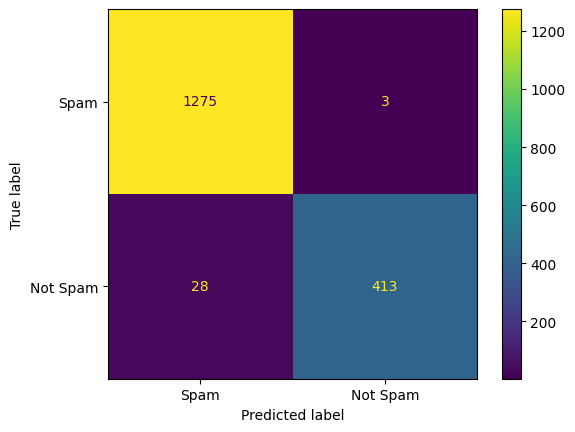

In [45]:
perform(y_test, y_pred_rf)

## Random Forest Tree Visualization (First Estimator)

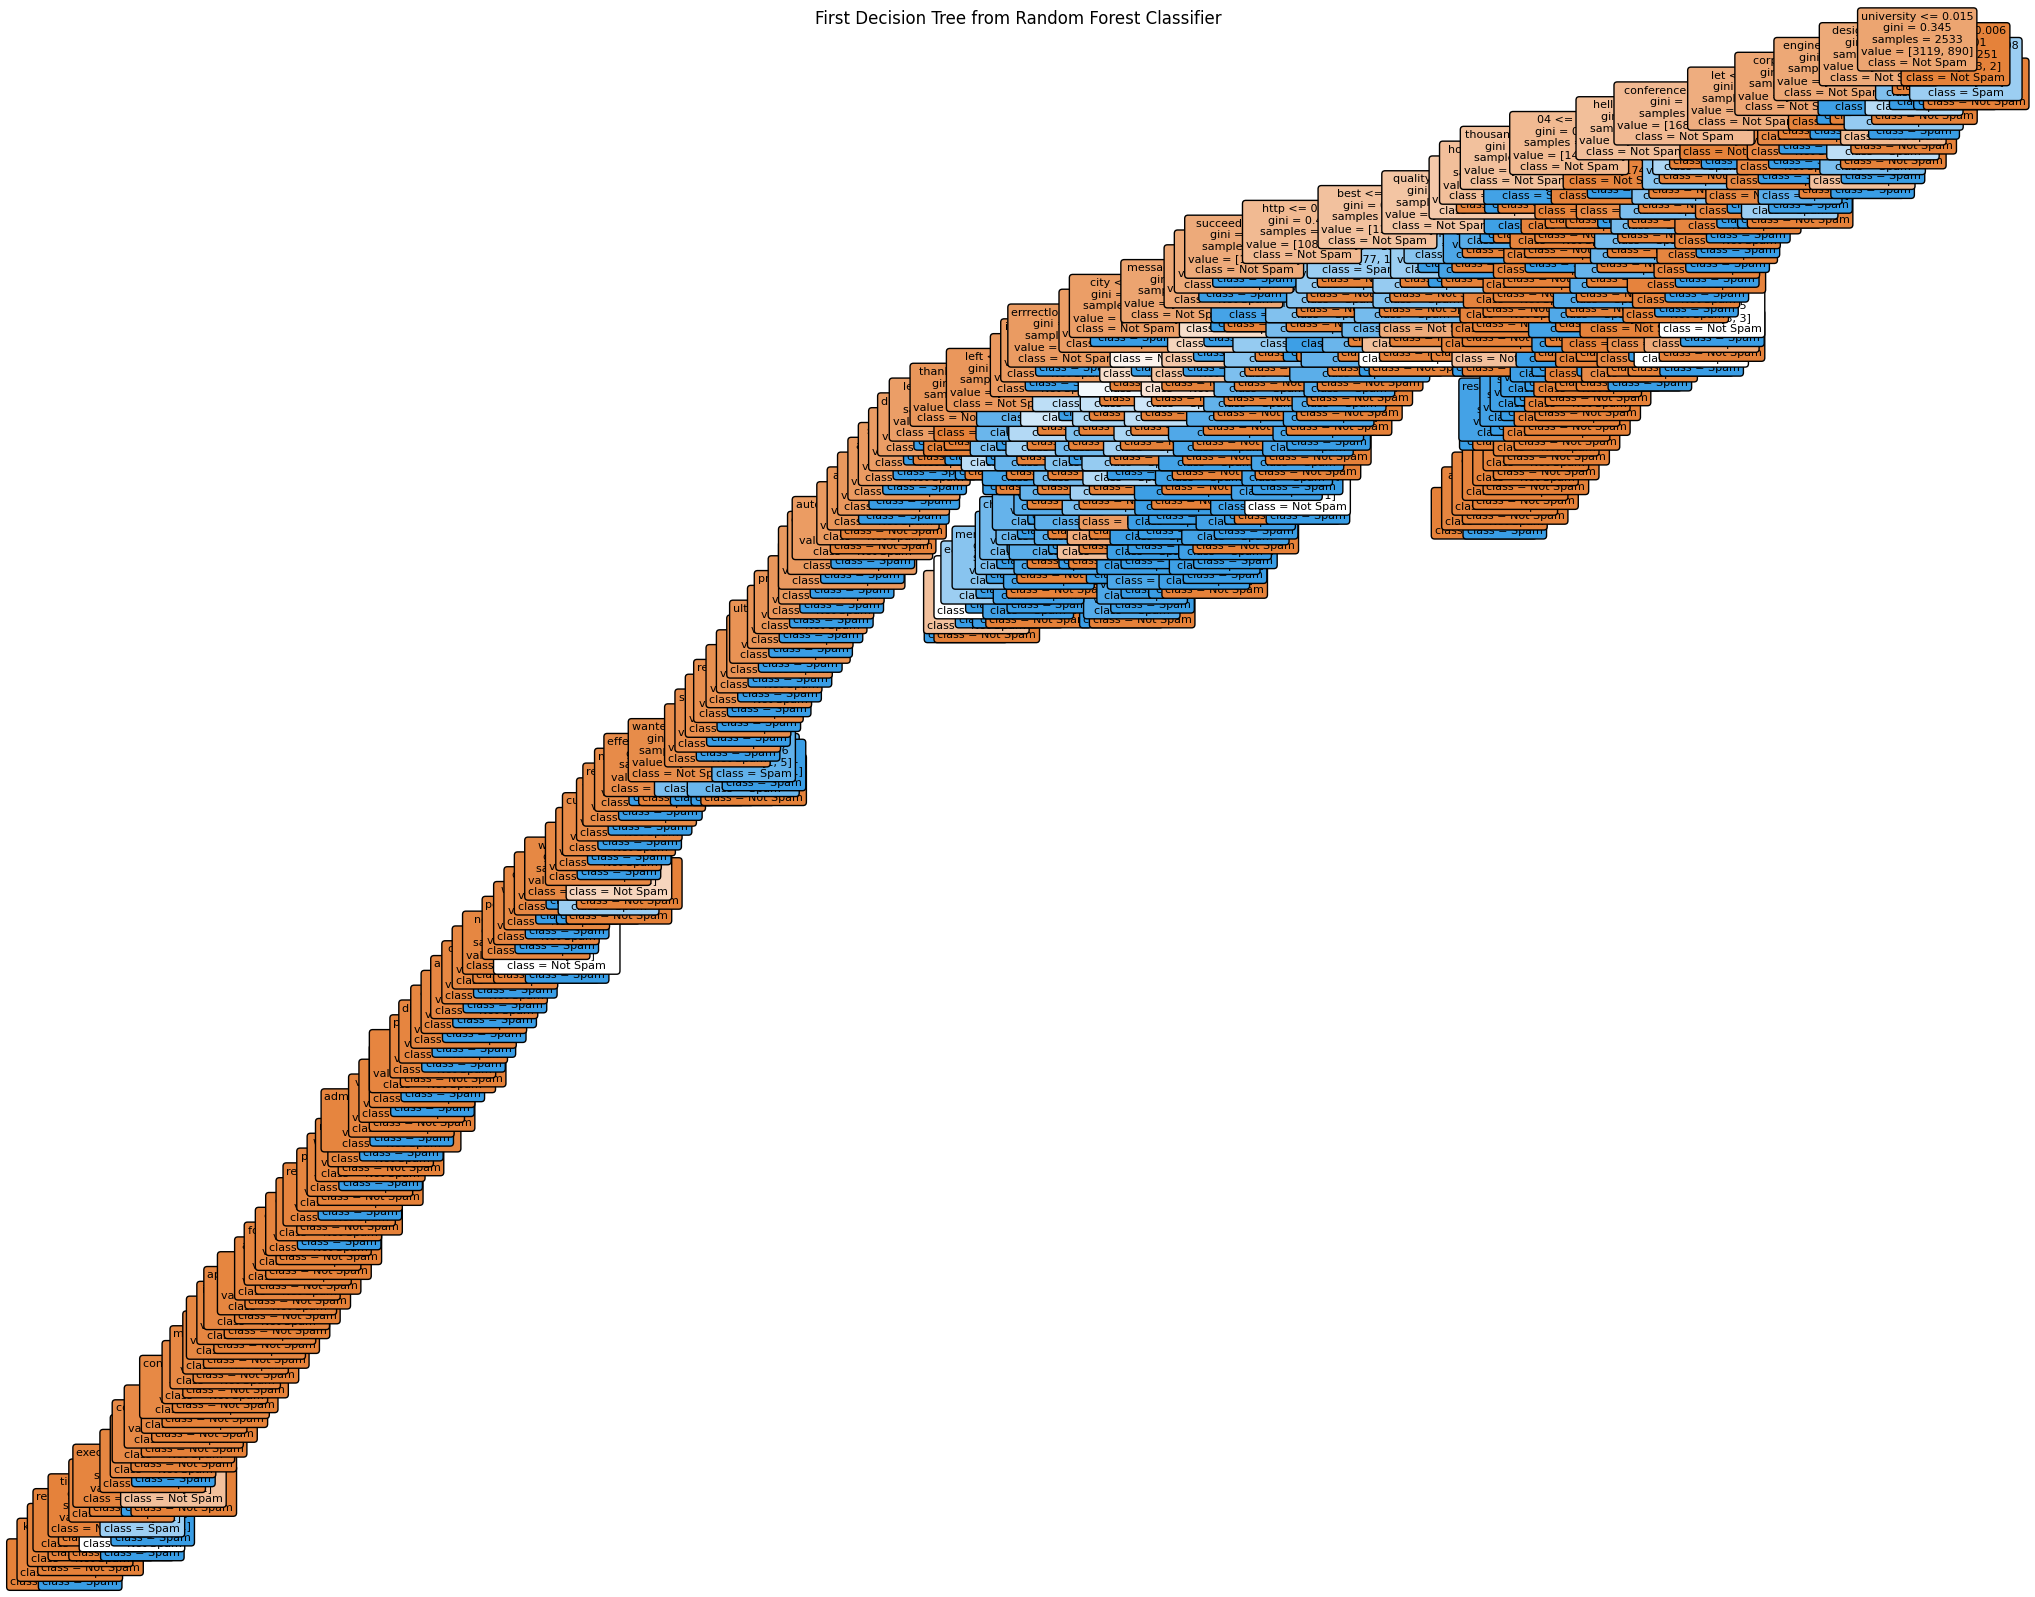

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


estimator = model_rf.estimators_[0]


plt.figure(figsize=(25,20))

# Visualize the first Decision Tree from the Random Forest
plot_tree(estimator,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8)

plt.title("First Decision Tree from Random Forest Classifier")
plt.show()

## Logistics Regression

In [47]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [48]:
y_pred_lr = model_lr.predict(X_test_tfidf)

Precision :  0.9902439024390244
Recall :  0.9206349206349206
Accuracy Score :  0.9773123909249564
F1 Score :  0.954171562867215

 [[1274    4]
 [  35  406]]



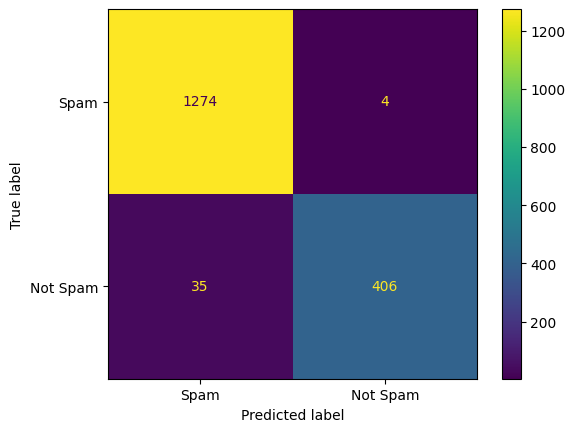

In [49]:
perform(y_test, y_pred_lr)

## Support Vector Classifier

In [50]:
model_svc = SVC()
model_svc.fit(X_train_tfidf, y_train)

SVC()

In [51]:
y_pred_svc = model_svc.predict(X_test_tfidf)

Precision :  0.9929245283018868
Recall :  0.9546485260770975
Accuracy Score :  0.9866201279813845
F1 Score :  0.9734104046242774

 [[1275    3]
 [  20  421]]



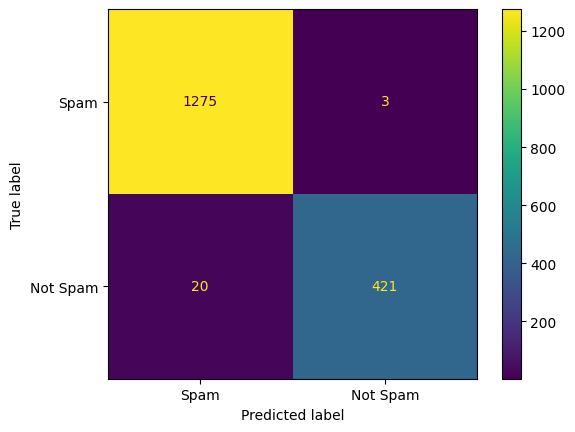

In [52]:
perform(y_test, y_pred_svc)

## Precision Recall Curve

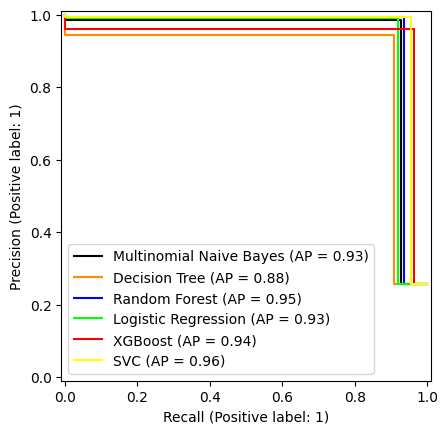

In [53]:
fig, ax = plt.subplots()
PrecisionRecallDisplay.from_predictions(y_test, y_pred_mnb, name=f"Multinomial Naive Bayes", color="black", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_dt, name=f"Decision Tree", color="darkorange", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_rf, name=f"Random Forest", color="blue", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_lr, name=f"Logistic Regression", color="lime", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_xgb, name=f"XGBoost", color="red", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_svc, name=f"SVC", color="yellow", ax=ax)

## ROC Curve

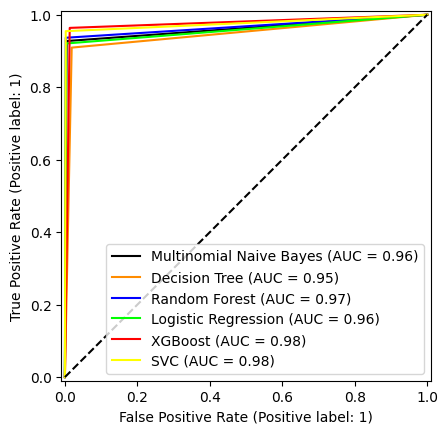

In [54]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_pred_mnb, name=f"Multinomial Naive Bayes", color="black", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_dt, name=f"Decision Tree", color="darkorange", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_rf, name=f"Random Forest", color="blue", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_lr, name=f"Logistic Regression", color="lime", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_xgb, name=f"XGBoost", color="red", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_svc, name=f"SVC", color="yellow", ax=ax)
plt.plot([0, 1], [0, 1], color="black", linestyle="--")


In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, average_precision_score, roc_auc_score

def get_performance_metrics(y_true, y_pred):
    """Calculates and returns a dictionary of performance metrics."""
    return {
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'Average Precision': average_precision_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_pred)
    }

In [59]:
model_performances = []

models = {
    'Multinomial Naive Bayes': y_pred_mnb,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Logistic Regression': y_pred_lr,
    'XGBoost': y_pred_xgb,
    'SVC': y_pred_svc
}

for model_name, y_pred in models.items():
    metrics = get_performance_metrics(y_test, y_pred)
    metrics['Model'] = model_name
    model_performances.append(metrics)

performance_df = pd.DataFrame(model_performances)

performance_df = performance_df[['Model', 'Precision', 'Recall', 'Accuracy', 'F1 Score', 'Average Precision', 'ROC AUC']]

display(performance_df)

,Model,Precision,Recall,Accuracy,F1 Score,Average Precision,ROC AUC
0,Multinomial Naive Bayes,0.985542,0.927438,0.977894,0.955607,0.932644,0.961371
1,Decision Tree,0.943529,0.909297,0.962769,0.926097,0.881218,0.945259
2,Random Forest,0.992788,0.936508,0.981966,0.963827,0.946043,0.967080
3,Logistic Regression,0.990244,0.920635,0.977312,0.954172,0.932014,0.958753
4,XGBoost,0.961538,0.963719,0.980803,0.962627,0.935960,0.975208
5,SVC,0.992925,0.954649,0.986620,0.973410,0.959529,0.976151
